# CS 559: Machine Learning - Assignment 3
**Name:** Lance DeCandia

**Date:** March 10, 2026

---
# Problem 1: Neural Networks

## Part (a): Forward Propagation

In [21]:
import numpy as np

def sigmoid(z):
    # logisitic sigmoid activation function
    return 1 / (1 + np.exp(-z))

def forward_prop(x, y, ws, bs):
    # x: inputs
    # y: outputs
    # ws: weights
    # bs: biases
    # zs: the z values
    # E: the total error
    zs = [x]  # zs[0] is the input layer
    a = x
    for W, b in zip(ws, bs):
        net = W @ a + b
        a = sigmoid(net)
        zs.append(a)
    
    # Total error: 0.5 * sum((y_hat - y)^2)
    E = 0.5 * np.sum((zs[-1] - y) ** 2)
    return zs, E

In [22]:
# Lecture example verification
x = np.array([0.7, 0.3, 0.5]).reshape(3, 1) # input column vector
y = np.array([1]).reshape(1, 1) # target output column vector
# weights[0]: hidden layer (2x3), weights[1]: output layer (1x2)
weights = [np.array([[-1.0, -2.3, 1.7],
                     [-0.8,  0.3, 1.4]]), np.array([[-2.0, -0.4]])]

# biases[0]: hidden layer (2x1), biases[1]: output layer (1x1)
biases  = [np.array([[1.6], [-0.6]]), np.array([[-0.5]])]

zs, E = forward_prop(x, y, weights, biases)
print(f'zs = {zs}')
print(f'E = {E}')

zs = [array([[0.7],
       [0.3],
       [0.5]]), array([[0.74269055],
       [0.40854102]]), array([[0.10444365]])]
E = 0.4010105918229552


## Part (b): Back Propagation

In [23]:
def back_prop(y, zs, ws, bs, eta):
    # Back propagation to update weights and biases.
    
    # Parameters:
        # y   : target column vector
        # zs  : list of activations from forward_prop
        # ws  : list of weight matrices
        # bs  : list of bias vectors
        # eta : learning rate
    
    # Returns:
        # ws : updated weight matrices
        # bs : updated bias vectors
    
    n_layers = len(ws)  # number of weight layers
    
    # Compute deltas from output layer backward
    deltas = [None] * n_layers
    
    # Output layer delta: (z_out - y) * sigmoid_deriv(z_out)
    z_out = zs[-1]
    deltas[-1] = (z_out - y) * z_out * (1 - z_out)
    
    # Hidden layer deltas (propagate backward)
    for l in range(n_layers - 2, -1, -1):
        z_l = zs[l + 1]
        deltas[l] = (ws[l + 1].T @ deltas[l + 1]) * z_l * (1 - z_l)
    
    # Update weights and biases
    # w_new = w_old - eta * (delta * activation_prev^T)
    # b_new = b_old - eta * delta
    new_ws = []
    new_bs = []
    for l in range(n_layers):
        new_ws.append(ws[l] - eta * (deltas[l] @ zs[l].T))
        new_bs.append(bs[l] - eta * deltas[l])
    
    return new_ws, new_bs

In [24]:
# Lecture example verification
# Uses zs and weights/biases from the forward_prop lecture example above
eta = 3.0
weights, biases = back_prop(y, zs, weights, biases, eta)
print(f'weights = {weights}')
print(f'biases = {biases}')

weights = [array([[-1.06723274, -2.32881403,  1.65197662],
       [-0.81700229,  0.2927133 ,  1.38785551]]), array([[-1.81336331, -0.29733444]])]
biases = [array([[ 1.50395323],
       [-0.62428899]]), array([[-0.24870195]])]


## Part (c): Run on New Example

In [25]:
# Input: 4 features, 2 outputs, 1 hidden layer with 3 neurons
x = np.array([5.2, -2.3, -1.7, 8.3]).reshape(4, 1) # input vector
y = np.array([0, 1]).reshape(2, 1) # target output
eta = 5.0 # learning rate

# Weights[0]: hidden layer (3x4), weights[1]: output layer (2x3)
weights = [np.array([
    [ 0.09, -0.68, -0.38, 0.93],
    [-0.37,  0.61,  0.45, 0.57],
    [-0.29, -0.76,  0.46, 0.01]]),
    np.array([[0.20, -0.20,  0.83],
              [0.35, -0.59,  0.36]])]

# Biases[0]: hidden layer (3x1), biases[1]: output layer (2x1)
biases = [np.array([[-0.53], [0.84], [-0.34]]), np.array([[-0.31], [0.36]])]

# Forward prop to get activations and error
zs, E = forward_prop(x, y, weights, biases)
print(f'zs = {zs}')
print(f'E = {E}')

# Run back prop to get upadeted weights and biases
weights, biases = back_prop(y, zs, weights, biases, eta)
print(f'weights = {weights}')
print(f'biases = {biases}')

zs = [array([[ 5.2],
       [-2.3],
       [-1.7],
       [ 8.3]]), array([[0.99994814],
       [0.81442149],
       [0.31023947]]), array([[0.4961511 ],
       [0.58447212]])]
E = 0.2094146646690716
weights = [array([[ 0.09001418, -0.68000627, -0.38000463,  0.93002263],
       [-0.50649493,  0.67037276,  0.49462334,  0.35213309],
       [-0.660631  , -0.59606706,  0.58116783, -0.5815841 ]]), array([[-0.42011997, -0.70506522,  0.63760433],
       [ 0.8545586 , -0.17905532,  0.51654211]])]
biases = [array([[-0.52999727],
       [ 0.81375097],
       [-0.41127519]]), array([[-0.93015212],
       [ 0.86458477]])]


---
# Problem 2: Training Data Process

In [26]:
# Import required libraries for data processing and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the hitters dataset
df = pd.read_csv('Hitters.csv')
print('Shape:', df.shape)
df.head()

Shape: (322, 20)


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


## Part (a): Train/Test Split (80/20)

In [27]:
# Dataset split 80/20 into training and test sets
# random_state is set for reproducibility
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f'Training set: {train_df.shape}')
print(f'Test set:     {test_df.shape}')

Training set: (257, 20)
Test set:     (65, 20)


## Part (b): EDA on Training Data

In [28]:
# Basic statistics
print('--- Data Types ---')
print(train_df.dtypes)
print('\n--- Missing Values ---')
print(train_df.isnull().sum())
print('\n--- Summary Statistics ---')
train_df.describe()

--- Data Types ---
AtBat          int64
Hits           int64
HmRun          int64
Runs           int64
RBI            int64
Walks          int64
Years          int64
CAtBat         int64
CHits          int64
CHmRun         int64
CRuns          int64
CRBI           int64
CWalks         int64
League        object
Division      object
PutOuts        int64
Assists        int64
Errors         int64
Salary       float64
NewLeague     object
dtype: object

--- Missing Values ---
AtBat         0
Hits          0
HmRun         0
Runs          0
RBI           0
Walks         0
Years         0
CAtBat        0
CHits         0
CHmRun        0
CRuns         0
CRBI          0
CWalks        0
League        0
Division      0
PutOuts       0
Assists       0
Errors        0
Salary       45
NewLeague     0
dtype: int64

--- Summary Statistics ---


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,212.000000
mean,379.408560,100.089494,10.836576,50.688716,47.579767,38.902724,7.354086,2608.284047,705.361868,69.097276,353.642023,323.867704,257.937743,295.793774,103.626459,8.093385,524.325505
std,154.389373,46.256289,8.634310,25.622645,26.654665,21.277424,4.946107,2348.254437,660.386468,86.303981,338.897806,329.746609,271.112011,288.398759,133.100234,6.412195,440.591424
min,19.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.000000,4.000000,0.000000,2.000000,3.000000,1.000000,0.000000,0.000000,0.000000,67.500000
25%,244.000000,61.000000,4.000000,31.000000,27.000000,22.000000,3.000000,711.000000,185.000000,12.000000,93.000000,80.000000,62.000000,110.000000,8.000000,3.000000,170.250000
50%,374.000000,96.000000,8.000000,47.000000,43.000000,35.000000,6.000000,1897.000000,491.000000,38.000000,246.000000,219.000000,174.000000,212.000000,40.000000,6.000000,422.500000
75%,517.000000,139.000000,16.000000,70.000000,63.000000,53.000000,11.000000,3859.000000,1000.000000,90.000000,513.000000,430.000000,326.000000,326.000000,150.000000,12.000000,750.000000
max,680.000000,223.000000,40.000000,119.000000,121.000000,105.000000,24.000000,14053.000000,4256.000000,548.000000,2165.000000,1659.000000,1566.000000,1378.000000,492.000000,32.000000,2460.000000


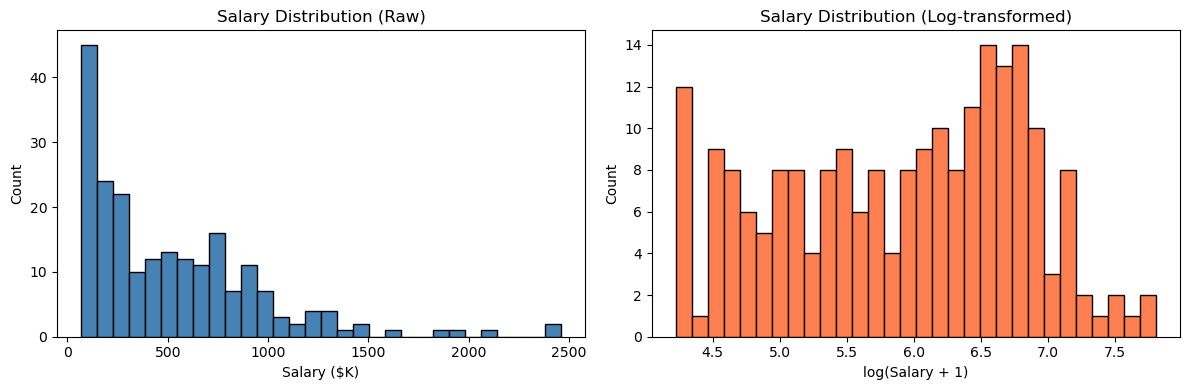


Salary missing values: 45 (17.5%)
The Salary column is right-skewed; log transformation yields a more normal distribution.
Given it is the only continuous variable without an obvious role as a feature, Salary is likely the prediction target.


In [29]:
# Salary distribution (likely target variable)
# Plot the raw and log-transformed Salary distributions side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left plot - raw Salary histogram
train_df['Salary'].dropna().plot(kind='hist', bins=30, ax=axes[0], edgecolor='black', color='steelblue')
axes[0].set_title('Salary Distribution (Raw)')
axes[0].set_xlabel('Salary ($K)')
axes[0].set_ylabel('Count')

# Right plot - log-transformed Salary histogram
np.log1p(train_df['Salary'].dropna()).plot(kind='hist', bins=30, ax=axes[1], edgecolor='black', color='coral')
axes[1].set_title('Salary Distribution (Log-transformed)')
axes[1].set_xlabel('log(Salary + 1)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Print missing value count and the percentage for the Salary
print(f"\nSalary missing values: {train_df['Salary'].isnull().sum()} ({train_df['Salary'].isnull().mean()*100:.1f}%)")

# Our conclusion from the above analysis:
print("The Salary column is right-skewed; log transformation yields a more normal distribution.")
print("Given it is the only continuous variable without an obvious role as a feature, Salary is likely the prediction target.")

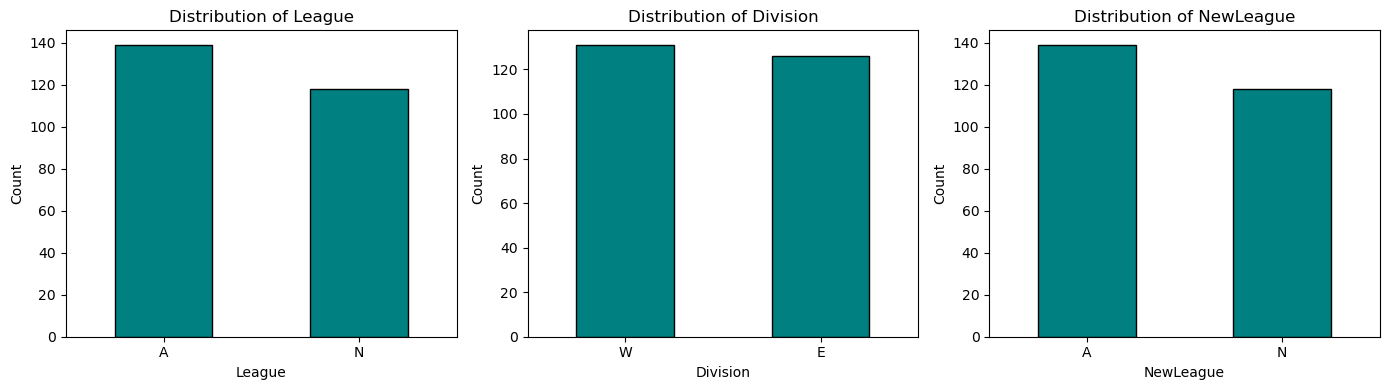

All three categorical features (League, Division, NewLeague) are binary (A/N or E/W).
Classes are roughly balanced across all three.


In [30]:
# Categorical columns exploration

# Plot the bar charts for all three categorical features
cat_cols = ['League', 'Division', 'NewLeague']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Loop through each categorical column and plot its value counts
for ax, col in zip(axes, cat_cols):
    train_df[col].value_counts().plot(kind='bar', ax=ax, color='teal', edgecolor='black')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

# Our conclusion from the above analysis:
print("All three categorical features (League, Division, NewLeague) are binary (A/N or E/W).")
print("Classes are roughly balanced across all three.")

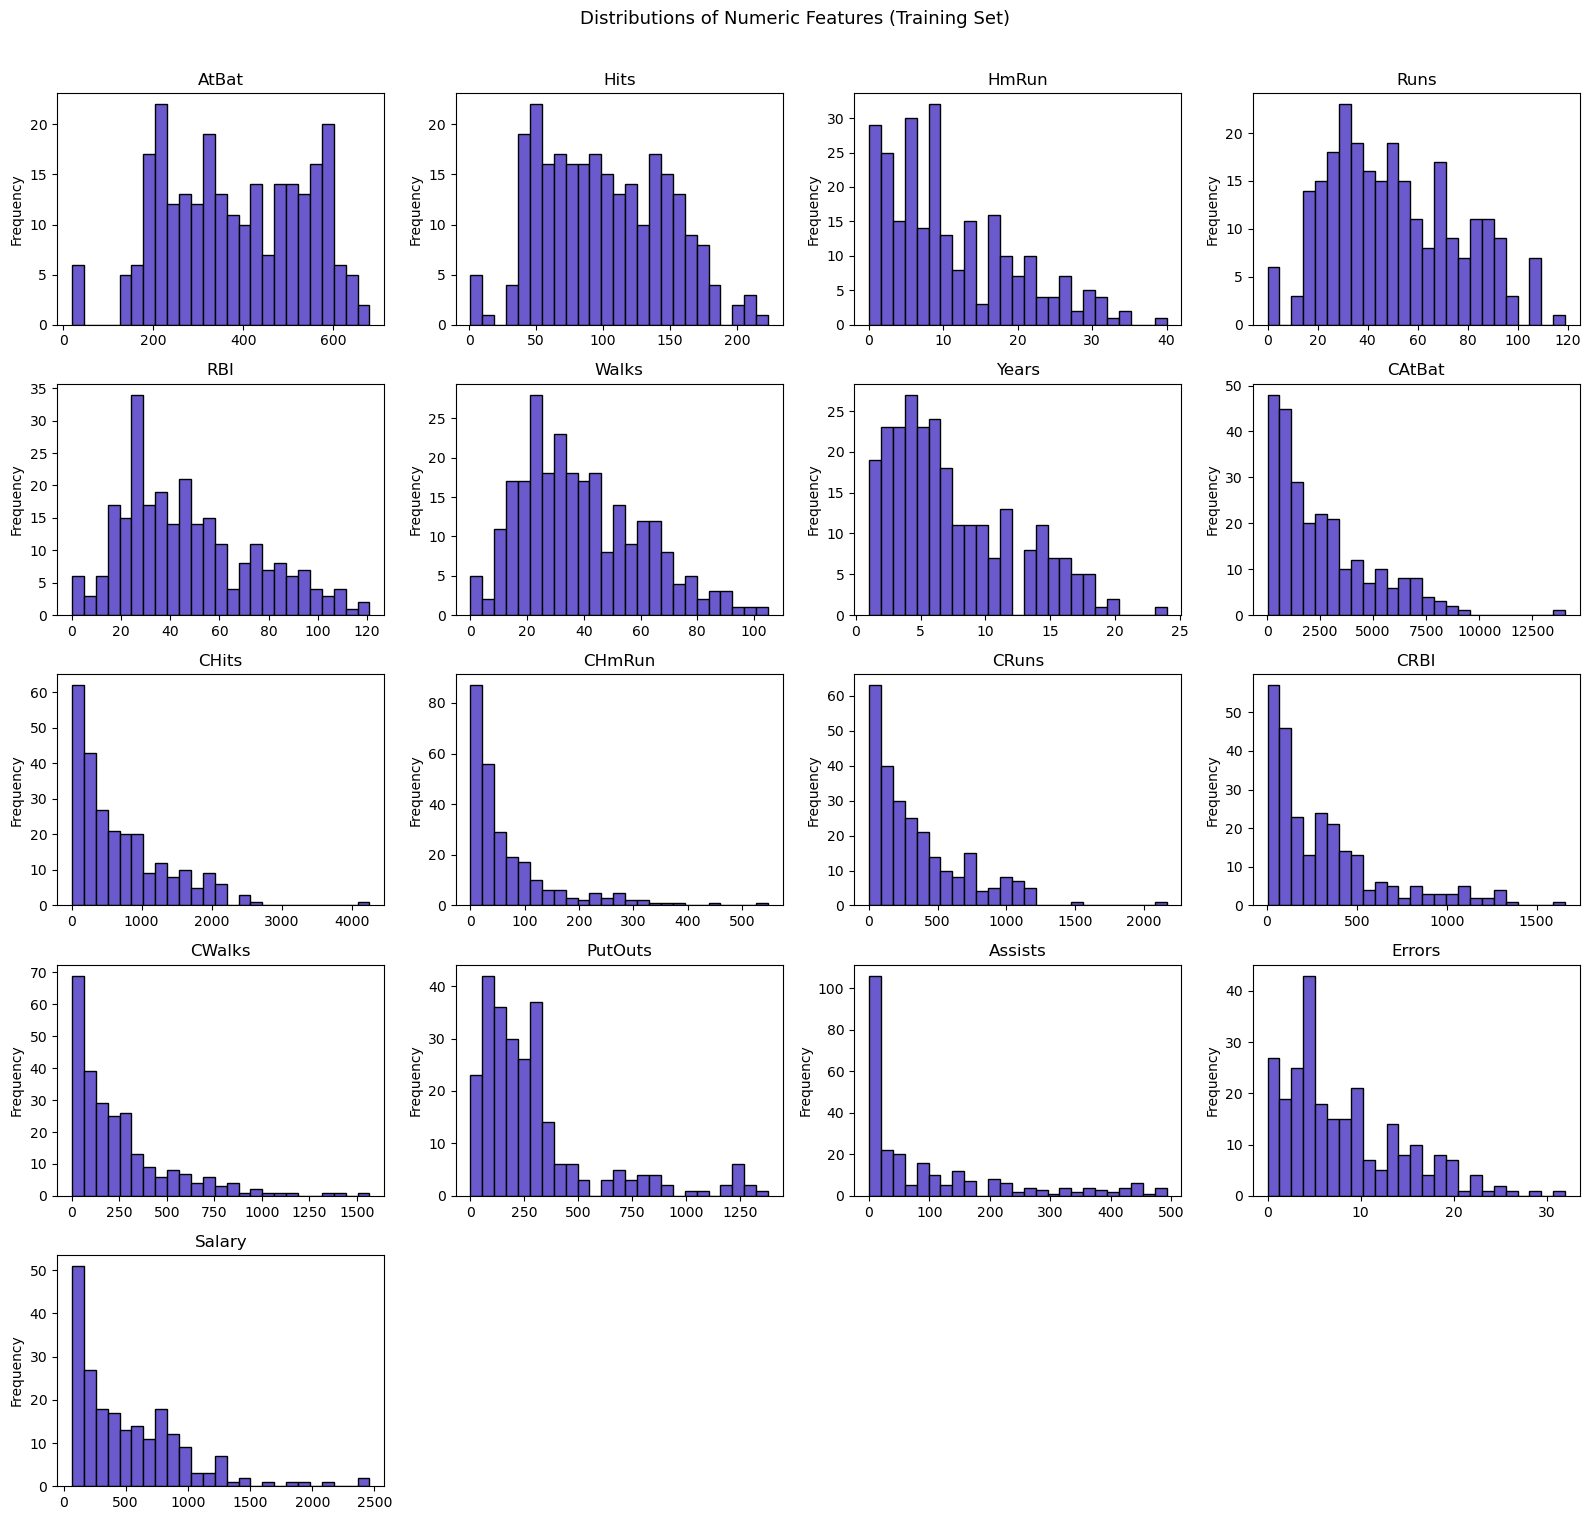

Many numeric features (e.g., CAtBat, CHits, CRuns, CRBI, CWalks, CHmRun) are right-skewed.
This is expected for career statistics — most players have short careers while a few accumulate large totals.


In [31]:
# Distribution of numeric features

# Plot the histograms for all of the numeric features
# Obtain all numeric column names
num_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()

# total number of numeric features
n = len(num_cols)
ncols = 4
# Calculate the number of rows needed to display all numeric features in a grid
nrows = (n + ncols - 1) // ncols
# Create subplot grid
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

# Plot each numberic feature as a histogram
for i, col in enumerate(num_cols):
    # Drop NaN values and plot histogram
    train_df[col].dropna().plot(kind='hist', bins=25, ax=axes[i], edgecolor='black', color='slateblue')
    # Use column name as title
    axes[i].set_title(col)
    # Remove x-axis label to reduce clutter
    axes[i].set_xlabel('')

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions of Numeric Features (Training Set)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

# Career statistics accumulate over time, so players with longer careers have much higher totals
print("Many numeric features (e.g., CAtBat, CHits, CRuns, CRBI, CWalks, CHmRun) are right-skewed.")
print("This is expected for career statistics — most players have short careers while a few accumulate large totals.")

In [32]:
# Correlation heatmap (numeric features)
corr = train_df[num_cols].corr()
# Display heatmap (borrowed from lecture notebook)
display(corr.style.background_gradient(cmap='coolwarm').set_caption('Correlation Matrix of Numeric Features (Training Set)'))

# Identify highly correlated pairs
high_corr = []
# Loop through upper traiangle of the correlation matrix to avoid duplicates
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        # Flag pairs with absolute correlation > 0.9
        if abs(corr.iloc[i, j]) > 0.9:
            high_corr.append((corr.columns[i], corr.columns[j], round(corr.iloc[i, j], 3)))

# Print all strongly correlated feature pairs 
print("Highly correlated pairs:")
for a, b, r in high_corr:
    print(f"  {a} vs {b}: {r}")

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
AtBat,1.000000,0.968319,0.611333,0.909512,0.825879,0.671355,0.071962,0.252760,0.268993,0.273525,0.274213,0.278621,0.160689,0.328586,0.359826,0.353119,0.355884
Hits,0.968319,1.000000,0.573273,0.920319,0.813539,0.650404,0.066448,0.243763,0.271113,0.234924,0.268453,0.263674,0.145687,0.303907,0.339622,0.316616,0.397925
HmRun,0.611333,0.573273,1.000000,0.655061,0.861743,0.504896,0.139020,0.238982,0.232229,0.511326,0.266969,0.376476,0.241623,0.290886,-0.029502,0.088188,0.329329
Runs,0.909512,0.920319,0.655061,1.000000,0.798619,0.738306,0.034717,0.205066,0.220604,0.264759,0.256234,0.242181,0.178058,0.259730,0.244275,0.244114,0.363059
RBI,0.825879,0.813539,0.861743,0.798619,1.000000,0.629316,0.167562,0.311403,0.322691,0.471975,0.331844,0.423562,0.251106,0.353172,0.147617,0.230060,0.430957
Walks,0.671355,0.650404,0.504896,0.738306,0.629316,1.000000,0.147351,0.275649,0.278166,0.368236,0.329525,0.329523,0.406012,0.314561,0.152020,0.138153,0.396815
Years,0.071962,0.066448,0.139020,0.034717,0.167562,0.147351,1.000000,0.917944,0.899545,0.723713,0.882961,0.865086,0.842432,0.023985,-0.056690,-0.127292,0.420521
CAtBat,0.252760,0.243763,0.238982,0.205066,0.311403,0.275649,0.917944,1.000000,0.994774,0.796431,0.984416,0.949686,0.906115,0.082447,0.028138,-0.026429,0.536878
CHits,0.268993,0.271113,0.232229,0.220604,0.322691,0.278166,0.899545,0.994774,1.000000,0.776748,0.985030,0.943425,0.886929,0.092606,0.028780,-0.017390,0.561361
CHmRun,0.273525,0.234924,0.511326,0.264759,0.471975,0.368236,0.723713,0.796431,0.776748,1.000000,0.817524,0.928705,0.806461,0.134444,-0.109144,-0.090727,0.546589


Highly correlated pairs:
  AtBat vs Hits: 0.968
  AtBat vs Runs: 0.91
  Hits vs Runs: 0.92
  Years vs CAtBat: 0.918
  CAtBat vs CHits: 0.995
  CAtBat vs CRuns: 0.984
  CAtBat vs CRBI: 0.95
  CAtBat vs CWalks: 0.906
  CHits vs CRuns: 0.985
  CHits vs CRBI: 0.943
  CHmRun vs CRBI: 0.929
  CRuns vs CRBI: 0.945
  CRuns vs CWalks: 0.924


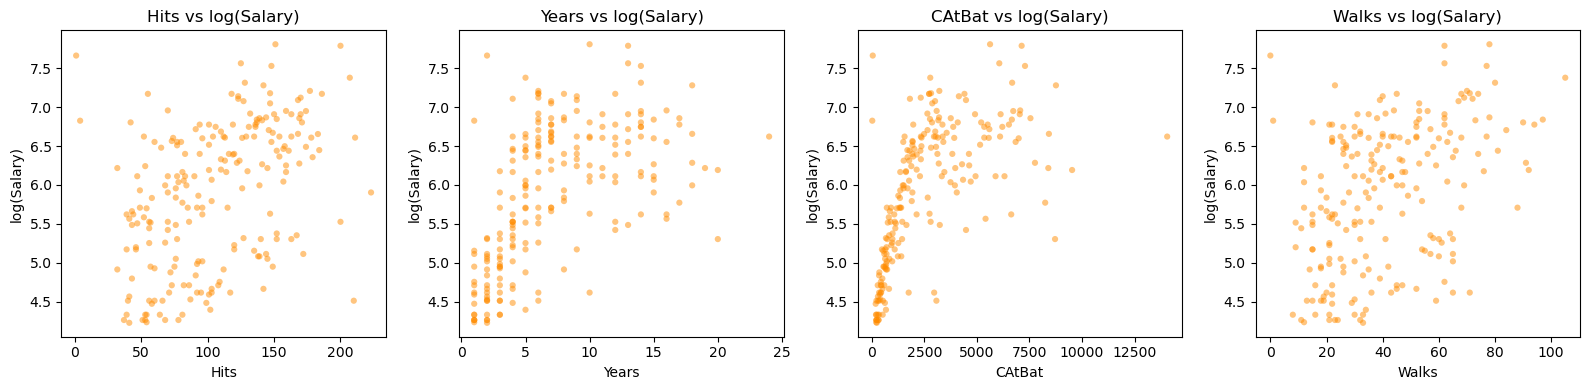

Career stats (CAtBat) and experience (Years) show a positive relationship with log(Salary).
Single-season stats like Hits show a weaker but still positive trend.


In [33]:
# Salary vs selected features (scatter)

# Scatte plots of selected features vs log(Salary) to visually assess relationships
# Remove rows with missing Salary for plotting
salary_present = train_df.dropna(subset=['Salary'])
# Features to examine against log(Salary)
plot_feats = ['Hits', 'Years', 'CAtBat', 'Walks']

# Create 1 row of 4 scatter plots
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Plot each feature against log(Salary)
for ax, feat in zip(axes, plot_feats):
    ax.scatter(salary_present[feat], np.log1p(salary_present['Salary']),
               alpha=0.5, edgecolors='none', color='darkorange', s=20)
    ax.set_xlabel(feat)
    ax.set_ylabel('log(Salary)')
    ax.set_title(f'{feat} vs log(Salary)')
plt.tight_layout()
plt.show()

# Players with more career at-bats and more years of experience tend to earn higher salaries
print("Career stats (CAtBat) and experience (Years) show a positive relationship with log(Salary).")
# Single season performance alone is not as strong an indicator of salary as career totals
print("Single-season stats like Hits show a weaker but still positive trend.")

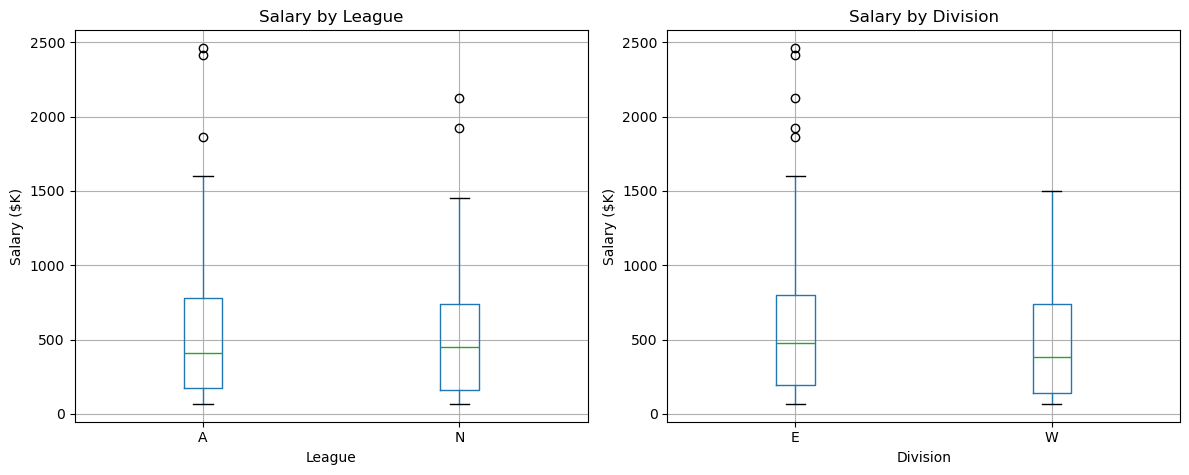

Salary distributions appear similar across Leagues (A vs N) and Divisions (E vs W),
though the National League median is slightly lower. These are still likely useful categorical features.


In [34]:
# Boxplot of Salary by League and Division
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes, ['League', 'Division']):
    salary_present.boxplot(column='Salary', by=col, ax=ax)
    ax.set_title(f'Salary by {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Salary ($K)')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Salary ranges are similar across both leagues and divisions
print("Salary distributions appear similar across Leagues (A vs N) and Divisions (E vs W),")
# Small differences do exist but these features may still carry predictive value
print("though the National League median is slightly lower. These are still likely useful categorical features.")

In [35]:
# KS tests: check whether log-transforming Salary and skewed features improves normality
# Was unsure if this was needed for EDA analysis

# Reject null if p value is less than 0.05, which means data is not normally distributed
from scipy.stats import kstest

# Get the Salary values from training set and drop the missing values
salary_vals = train_df['Salary'].dropna()
# Apply log transformation to Salary
log_salary_vals = np.log1p(salary_vals)

# Standardize raw Salary and run KS test against normal distribution
ks_raw = kstest((salary_vals - salary_vals.mean()) / salary_vals.std(), 'norm')
# Standardize log Salary and run KS test against normal distribution
ks_log = kstest((log_salary_vals - log_salary_vals.mean()) / log_salary_vals.std(), 'norm')

# Print the KS test results for raw and log-transformed Salary
print('KS test for normality (null: data is normally distributed, reject if p < 0.05):')
print(f'  Raw Salary:    statistic={ks_raw.statistic:.4f}, p-value={ks_raw.pvalue:.4f}')
print(f'  log(Salary):   statistic={ks_log.statistic:.4f}, p-value={ks_log.pvalue:.4f}')
print('   log(Salary) has a higher p-value, indicating the log transform brings it closer to normal.')
print()

# Repeat the KS rest for other right-skewed features
print('KS tests for normality on selected skewed features (raw vs log-transformed):')
for col in ['CAtBat', 'PutOuts']:
    # Get feature values and apply log transformation
    x = train_df[col].dropna()
    x_log = np.log1p(x)
    ks_r = kstest((x - x.mean()) / x.std(), 'norm')
    ks_l = kstest((x_log - x_log.mean()) / x_log.std(), 'norm')
    # A higher p value after the log transform confirms improved normality
    print(f'  {col}: raw p={ks_r.pvalue:.4f} log p={ks_l.pvalue:.4f} (log transform improves normality)')

KS test for normality (null: data is normally distributed, reject if p < 0.05):
  Raw Salary:    statistic=0.1499, p-value=0.0001
  log(Salary):   statistic=0.0886, p-value=0.0674
   log(Salary) has a higher p-value, indicating the log transform brings it closer to normal.

KS tests for normality on selected skewed features (raw vs log-transformed):
  CAtBat: raw p=0.0001 log p=0.0855 (log transform improves normality)
  PutOuts: raw p=0.0000 log p=0.0000 (log transform improves normality)


### EDA Summary

**Key findings:**
1. **Salary** has ~59 missing values and is the likely prediction target; it is right-skewed, so a log transform is appropriate.
2. **Multicollinearity:** Career statistics (CAtBat, CHits, CRuns, CRBI, CWalks) are strongly correlated with each other (|r| > 0.90), as are some single-season stats (AtBat ↔ Hits). Including all of them would introduce redundancy.
3. **Categorical features** (League, Division, NewLeague) are binary and well-balanced; they need to be one-hot or label encoded.
4. Several numeric features are right-skewed and may benefit from log or sqrt transforms to stabilize variance.

## Part (c): Feature Selection / Extraction / Engineering on Training Set

In [36]:
# *I orignally had this into multiple parts, but on the rubric for canvas it says that for 2d we should have the data transformation as something modular (e.g. a function)
# By wrapping all the transformations into a single function we can apply the exact same pipeline to the training and test sets
def preprocess(df, scaler, fit=False):
    # df     : raw DataFrame (train or test)
    # scaler : StandardScaler instance
    # fit    : if True, fit the scaler on this data (use for training set only)
    
    # returns a processed DataFrame with scaled features and log_Salary target

    # Drop rows where Salary is missing since it is the target variable
    data = df.dropna(subset=['Salary']).copy()

    # Step 1-2: Log-transform Salary and set as target
    # log1p = log(x+1) to handle any zero values
    data['log_Salary'] = np.log1p(data['Salary'])
    # Remove original Salary column since log_Salary replaces it
    data.drop(columns=['Salary'], inplace=True)

    # Step 3: Encode binary categorical features as integers
    # League: American=0, National=1
    data['League']    = (data['League']    == 'N').astype(int)
    # Division: East=0, West=1
    data['Division']  = (data['Division']  == 'W').astype(int)
    # NewLeague: American=0, National=1
    data['NewLeague'] = (data['NewLeague'] == 'N').astype(int)

    # Step 4: Engineer career rate features
    # Career totals are highly correlated with each other (|r|>0.9)
    eps = 1e-6
    # Career batting average: hits per at-bat over career
    data['CareerBatAvg']   = data['CHits']  / (data['CAtBat'] + eps)
    # Career home run rate: home runs per at-bat over career
    data['CareerHRRate']   = data['CHmRun'] / (data['CAtBat'] + eps)
    # Career run rate: runs per at-bat over career
    data['CareerRunRate']  = data['CRuns']  / (data['CAtBat'] + eps)
    # Career RBI rate: RBIs per at-bat over career
    data['CareerRBIRate']  = data['CRBI']   / (data['CAtBat'] + eps)
    # Career walk rate: walks per at-bat over career
    data['CareerWalkRate'] = data['CWalks'] / (data['CAtBat'] + eps)
    # Single-season batting average: hits per at-bat this season
    data['BatAvg']         = data['Hits']   / (data['AtBat']  + eps)

    # Step 5: Drop raw career total columns now replaced by rate features
    # CAtBat is kept as a proxy for career length and experience
    drop_cols = ['CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'AtBat']
    data.drop(columns=drop_cols, inplace=True)

    # Step 6: Log-transform remaining right-skewed numeric features
    for col in ['CAtBat', 'PutOuts']:
        # Apply log1p transformation to reduce skewness
        data[col] = np.log1p(data[col])
        # Rename column to indicate it has been log-transformed
        data.rename(columns={col: f'log_{col}'}, inplace=True)

    # Step 7: Standardize all features to zero mean and unit variance
    target_col = 'log_Salary'
    # Get all feature columns except the target
    feature_cols = [c for c in data.columns if c != target_col]
    if fit:
        # Fit scaler on training data and transform
        data[feature_cols] = scaler.fit_transform(data[feature_cols])
    else:
        # Apply already-fitted scaler to test data (no re-fitting)
        data[feature_cols] = scaler.transform(data[feature_cols])

    # Reset index and return cleaned, processed DataFrame
    return data.reset_index(drop=True)

In [37]:
# Apply to training set — fit=True so scaler is fitted here
scaler = StandardScaler()
train_processed = preprocess(train_df, scaler, fit=True)

print(f'Final training set shape: {train_processed.shape}')
print('Features:', [c for c in train_processed.columns if c != 'log_Salary'])
train_processed.head()

Final training set shape: (212, 20)
Features: ['Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'log_CAtBat', 'League', 'Division', 'log_PutOuts', 'Assists', 'Errors', 'NewLeague', 'CareerBatAvg', 'CareerHRRate', 'CareerRunRate', 'CareerRBIRate', 'CareerWalkRate', 'BatAvg']


,Hits,HmRun,Runs,RBI,Walks,Years,log_CAtBat,League,Division,log_PutOuts,Assists,Errors,NewLeague,log_Salary,CareerBatAvg,CareerHRRate,CareerRunRate,CareerRBIRate,CareerWalkRate,BatAvg
0,0.900078,2.024285,1.222064,1.528474,1.403161,-0.263565,0.485310,-0.981307,1.0,1.467393,-0.063650,0.217682,-0.972088,7.178545,1.159128,1.058469,0.542341,1.558953,0.497071,0.174592
1,-1.330533,-1.125214,-1.185940,-1.628961,-1.238502,-0.467492,-1.149308,-0.981307,1.0,-0.430393,0.455890,1.125521,-0.972088,5.170484,-2.101377,-0.972166,0.176895,-2.190009,-0.468805,-0.588190
2,1.363869,0.741156,0.748358,1.946929,-0.059188,2.183552,1.497251,-0.981307,-1.0,1.365829,0.313550,0.822908,-0.972088,6.656298,1.290446,-0.382766,-0.544905,0.279197,-1.490375,0.169073
3,-1.065509,-0.658622,-0.791185,-1.058340,-0.908294,-1.283198,-2.045093,1.019049,1.0,-0.542593,-0.803817,-0.841464,1.028714,4.471639,2.481867,0.510233,2.523279,0.273474,0.747644,1.786061
4,0.480459,0.507859,0.629932,0.843729,1.827714,1.367847,1.282321,-0.981307,1.0,-0.468610,0.747686,1.125521,-0.972088,7.313887,2.201142,0.390241,1.297302,1.215537,0.219346,0.870976


### Feature Engineering / Selection Summary

| Decision | Reasoning |
|---|---|
| Drop rows with missing Salary | Target must be known for supervised learning |
| Log-transform Salary -> log_Salary | Right-skewed target; log normalizes distribution |
| Encode League, Division, NewLeague | Binary categorical -> binary integer |
| Derive career rate features (CareerBatAvg, etc.) | Removes multicollinearity among career totals; rate stats generalize better across players with different career lengths |
| Drop CHits, CHmRun, CRuns, CRBI, CWalks, AtBat | Replaced by derived rates; reduces redundancy |
| Log-transform CAtBat, PutOuts | Right-skewed; log stabilizes variance |
| StandardScaler (fit on train only) | Ensures zero-mean unit-variance without leaking test info |

## Part (d): Apply Same Transformations to Test Set

In [38]:
# Apply identical pipeline to test set using the already-fitted scaler (fit=False)
test_processed = preprocess(test_df, scaler, fit=False)

print(f'Final test set shape: {test_processed.shape}')
test_processed.head()

Final test set shape: (51, 20)


,Hits,HmRun,Runs,RBI,Walks,Years,log_CAtBat,League,Division,log_PutOuts,Assists,Errors,NewLeague,log_Salary,CareerBatAvg,CareerHRRate,CareerRunRate,CareerRBIRate,CareerWalkRate,BatAvg
0,-0.800486,-0.541974,-1.264891,-0.525761,-1.096984,2.183552,1.350448,-0.981307,1.0,-3.989889,-0.803817,-1.295384,-0.972088,5.786897,1.166515,0.072325,-0.074422,1.031751,-0.224471,-0.294403
1,-0.314611,0.624508,-0.199053,0.577439,1.120125,1.163920,1.052767,-0.981307,-1.0,-3.989889,-0.803817,-1.295384,-0.972088,7.003974,-0.271676,1.518610,0.847167,1.640993,2.105729,-0.972464
2,-0.469208,-1.008566,-0.949087,-0.259471,-1.002639,0.144288,0.231847,-0.981307,-1.0,-0.517131,0.512826,0.520295,-0.972088,5.895779,0.136002,-1.165490,-1.387399,-0.657496,-1.619602,-0.047685
3,-1.198021,-0.425325,-0.909612,-0.906174,-1.144157,0.959994,1.039906,-0.981307,-1.0,-0.111573,-0.782466,-0.992771,-0.972088,5.993961,-0.193432,-0.941536,-0.293584,-0.985291,-0.226762,-0.238031
4,0.679226,-1.125214,0.156226,-0.145347,-1.380019,-1.079271,-0.436001,-0.981307,1.0,0.286629,2.462880,2.033360,-0.972088,5.170484,-0.049103,-1.464862,-0.337051,-1.284622,-2.236098,-0.335062


In [39]:
# Verify structures match and that train and test have identical columns
assert list(train_processed.columns) == list(test_processed.columns), "Column mismatch!"
print('Train and test sets have identical structure.')
print(f'Train shape: {train_processed.shape}')
print(f'Test shape:  {test_processed.shape}')

Train and test sets have identical structure.
Train shape: (212, 20)
Test shape:  (51, 20)


## Part (e): Save Processed Datasets

In [40]:
# Save processed train and test sets to CSV for use in the following assignment
train_processed.to_csv('hitters_train_processed.csv', index=False)
test_processed.to_csv('hitters_test_processed.csv', index=False)
print('Saved: hitters_train_processed.csv')
print('Saved: hitters_test_processed.csv')

Saved: hitters_train_processed.csv
Saved: hitters_test_processed.csv
